In [1]:
%matplotlib inline

from quick_pp.objects import Project

# Load well from saved file
project_name = "30-7"
project_path = rf"data\04_project\{project_name}.qppp"
project = Project().load(project_path)
project.get_well_names()

[2025-10-13 16:12:54] INFO     | quick_pp.objects | Project '' initialized with path: data\04_project\
[2025-10-13 16:12:54] INFO     | quick_pp.objects | Loading project from: data\04_project\30-7.qppp


c:\projects\pp_portfolio\.venv\Lib\site-packages\welly\__init__.py:69: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


['30-7a-1', '30-7a-2', '30-7a-6', '30-7a-7', '30-7a-8']

# Quick PP Interpretation

[2025-10-13 16:12:55] INFO     | quick_pp.objects | Loading well from: data\04_project\30-7\30-7a-1.qppw
[2025-10-13 16:12:55] INFO     | quick_pp.objects | Loading well from: data\04_project\30-7\30-7a-2.qppw
[2025-10-13 16:12:55] INFO     | quick_pp.objects | Loading well from: data\04_project\30-7\30-7a-6.qppw
[2025-10-13 16:12:55] INFO     | quick_pp.objects | Loading well from: data\04_project\30-7\30-7a-7.qppw
[2025-10-13 16:12:55] INFO     | quick_pp.objects | Loading well from: data\04_project\30-7\30-7a-8.qppw


Analyzing cutoffs: 100%|██████████| 100/100 [00:00<00:00, 2223.66it/s]

[2025-10-13 16:12:55] INFO     | quick_pp.ressum | Optimal cutoffs found - Vshale: 0.758, PHIT: 0.061, SWT: 0.960


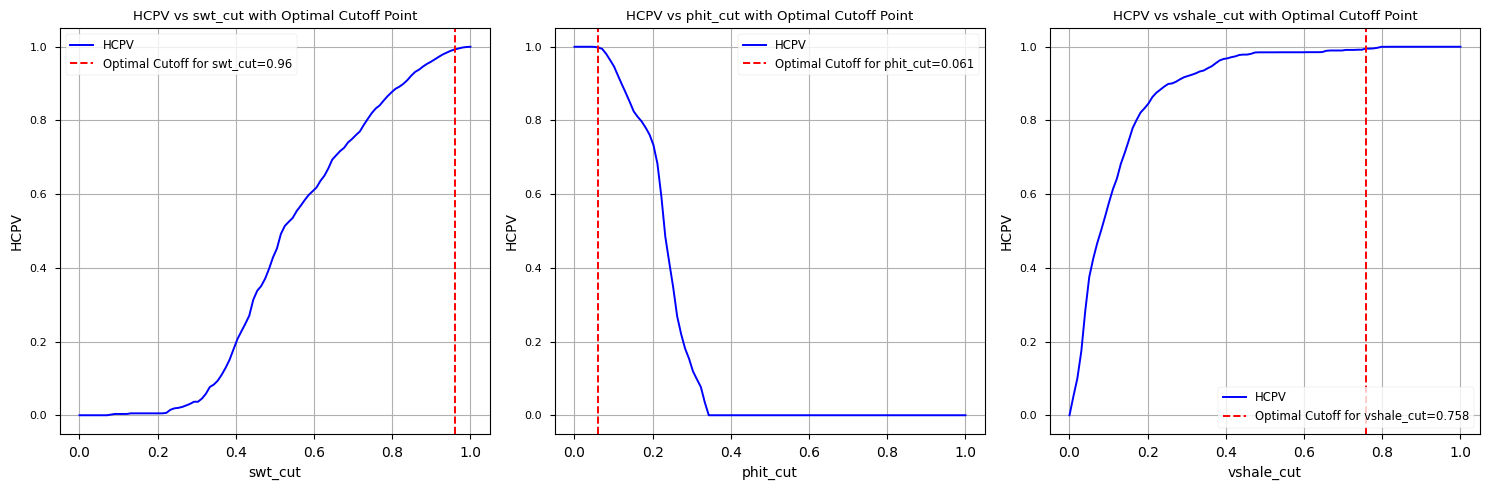

In [2]:
from quick_pp.ressum import cutoffs_analysis
from quick_pp.machine_learning.feature_engineering import tight_streak_flagging, coal_flagging

# Plot individual results
final_df = project.get_all_data()
final_df['DTC'] = final_df.DT
final_df['BVW'] = final_df.SWT * final_df.PHIE
final_df['VHC'] = (final_df.PHIE * (1 - final_df.SWT)).clip(0, 1)

final_df['VSHALE'] = final_df.VCLAY
cutoffs = cutoffs_analysis(final_df, percentile=95)

In [3]:
import pandas as pd
import numpy as np
import os

from quick_pp.plotter.plotter import plotly_log
from quick_pp.plotter.well_log_config import TRACE_DEFS, XAXIS_DEFS
from quick_pp.ressum import calc_reservoir_summary

font_size = 8
color = 'blue'
TRACE_DEFS['LLS'] = dict(
    track=2,
    secondary_y=False,
    hide_xaxis=False,
    style={'line_dash': 'dash', 'line_width': 1, 'line_color': color}
)
XAXIS_DEFS['LLS'] = dict(
    title={'text': 'LLS (ohm.m)', 'font': {'color': color, 'size': font_size}},
    tickfont={'color': color, 'size': font_size},
    side='top', anchor='free', position=.89,
    title_standoff=.1, range=[np.log10(.2), np.log10(2000)], type='log', overlaying='x2',
    tickmode='array', tickvals=np.geomspace(0.2, 2000, 5), tickangle=-90, minor_showgrid=True
)

color = 'gray'
TRACE_DEFS['MSFL'] = dict(
    track=2,
    secondary_y=False,
    hide_xaxis=False,
    style={'line_dash': 'dashdot', 'line_width': 1, 'line_color': color}
)
XAXIS_DEFS['MSFL'] = dict(
    title={'text': 'MSFL (ohm.m)', 'font': {'color': color, 'size': font_size}},
    tickfont={'color': color, 'size': font_size},
    side='top', anchor='free', position=.93,
    title_standoff=.1, range=[np.log10(.2), np.log10(2000)], type='log', overlaying='x2',
    tickmode='array', tickvals=np.geomspace(0.2, 2000, 5), tickangle=-90, minor_showgrid=True
)

color = 'magenta'
TRACE_DEFS['SP'] = dict(
    track=2,
    secondary_y=False,
    hide_xaxis=False,
    style={'line_dash': 'dot', 'line_width': 1, 'line_color': color, 'fill': 'toself'}
)
XAXIS_DEFS['SP'] = dict(
    title={'text': 'SP (mV)', 'font': {'color': color, 'size': font_size}},
    tickfont={'color': color, 'size': font_size},
    side='top', anchor='free', position=.97, showgrid=False, zeroline=False,
    title_standoff=.1, dtick=40, range=[0, 200], type='linear', overlaying='x2'
)

color = 'red'
TRACE_DEFS['URAN'] = dict(
    track=1,
    secondary_y=False,
    hide_xaxis=False,
    style={'line_dash': 'dot', 'line_width': 1, 'line_color': color}
)
XAXIS_DEFS['URAN'] = dict(
    title={'text': 'URAN (ppm)', 'font': {'color': color, 'size': font_size}},
    tickfont={'color': color, 'size': font_size},
    side='top', anchor='free', position=.82, showgrid=False, zeroline=False,
    title_standoff=.1, dtick=40, range=[0, 10], type='linear', overlaying='x1'
)

color = 'gray'
TRACE_DEFS['POTA.'] = dict(
    track=1,
    secondary_y=False,
    hide_xaxis=False,
    style={'line_dash': 'dot', 'line_width': 1, 'line_color': color}
)
XAXIS_DEFS['POTA.'] = dict(
    title={'text': 'POTA (%)', 'font': {'color': color, 'size': font_size}},
    tickfont={'color': color, 'size': font_size},
    side='top', anchor='free', position=.79, showgrid=False, zeroline=False,
    title_standoff=.1, dtick=40, range=[0, 10], type='linear', overlaying='x1'
)

color = 'green'
TRACE_DEFS['THOR'] = dict(
    track=1,
    secondary_y=False,
    hide_xaxis=False,
    style={'line_dash': 'dot', 'line_width': 1, 'line_color': color}
)
XAXIS_DEFS['THOR'] = dict(
    title={'text': 'THOR (ppm)', 'font': {'color': color, 'size': font_size}},
    tickfont={'color': color, 'size': font_size},
    side='top', anchor='free', position=.76, showgrid=False, zeroline=False,
    title_standoff=.1, dtick=40, range=[0, 10], type='linear', overlaying='x1'
)

In [4]:
import pandas as pd
import numpy as np
import os

from quick_pp.plotter.plotter import plotly_log
from quick_pp.plotter.well_log_config import TRACE_DEFS, XAXIS_DEFS
from quick_pp.ressum import calc_reservoir_summary

args = {
    'ressum_cutoffs': dict(
        VSHALE=.7,
        PHIT=0.2,
        SWT=1
    )
}

output_folder = r'data\04_project\nb_outputs'
os.makedirs(output_folder, exist_ok=True)
ressum_merged = pd.DataFrame()
for well, data in final_df.groupby('WELL_NAME'):
    
    # Flag tight streaks and coal
    data['VHALI'] = np.where(data.ZONES == 'Zechstein', 1, 0)
    data['TIGHT_FLAG'] = tight_streak_flagging(data.RHOB)
    data['COAL_FLAG'] = coal_flagging(data.NPHI, data.RHOB)

    fig = plotly_log(
        data, well_name=well, depth_uom='m', column_widths=[1, 1, 1, 1, 1, 1, .3, 1, 1],
        trace_defs=TRACE_DEFS, xaxis_defs=XAXIS_DEFS
    )
    # fig.show(config=dict(scrollZoom=True))
    fig.write_html(rf"{output_folder}\{well}_log.html", config=dict(scrollZoom=True))
    # break

    ressum_df = calc_reservoir_summary(
        data.DEPTH, data.VCLAY, data.PHIT, data.SWT, data.PERM,
        zones=data['ZONES'], cutoffs=args['ressum_cutoffs']
    )
    ressum_df.insert(0, 'WELL_NAME', well)
    ressum_merged = pd.concat([ressum_merged, ressum_df])
ressum_merged['WELL_NAME'] = ressum_merged['WELL_NAME'].str.replace('-', '/', 1).str.replace('-', ' ')
ressum_merged.to_csv(os.path.join(output_folder, f'{project_name}_ressum.csv'), index=False)

c:\projects\pp_portfolio\.venv\Lib\site-packages\quick_pp\ressum.py:55: RuntimeWarning:

Mean of empty slice

c:\projects\pp_portfolio\.venv\Lib\site-packages\quick_pp\ressum.py:56: RuntimeWarning:

Mean of empty slice

c:\projects\pp_portfolio\.venv\Lib\site-packages\quick_pp\ressum.py:58: RuntimeWarning:

Mean of empty slice

c:\projects\pp_portfolio\.venv\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning:

Mean of empty slice.

c:\projects\pp_portfolio\.venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

c:\projects\pp_portfolio\.venv\Lib\site-packages\numpy\lib\function_base.py:520: RuntimeWarning:

Mean of empty slice.

c:\projects\pp_portfolio\.venv\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning:

invalid value encountered in scalar divide

c:\projects\pp_portfolio\.venv\Lib\site-packages\quick_pp\ressum.py:55: RuntimeWarning:

Mean of empty slice

c:\projects\pp_portfolio\.venv\Lib\site-pack

In [5]:
STOP

NameError: name 'STOP' is not defined

In [ ]:
from quick_pp.qaqc import quick_compare

compare_df, fig = quick_compare(final_df, return_fig=True)

### Fluid Contact Analysis

In [ ]:
import pprint
from quick_pp.plotter.plotter import stick_plot, generate_well_config
pp = pprint.PrettyPrinter(indent=4)

well_names = project.get_well_names()
well_config = generate_well_config(well_names)

from quick_pp.plotter.plotter import update_well_config

WUT = 3380
ODT = 3366
OUT = 3030

ZONE = 'ALL'
for well in well_names:
    fluid_dict = {
        'OUT': OUT,
        'ODT': ODT,
        'WUT': WUT,
    }
    well_config = update_well_config(well_config, well, ZONE, fluid_dict)

sorting_dict = {
    '2-5-1': 2,
    '2-5-2': 3,
    '2-5-3': 4,
    '2-5-4': 5,
    '2-5-6': 6,
    '2-5-7': 1,
}

for well, sorting in sorting_dict.items():
    well_config = update_well_config(well_config, well, sorting=sorting)

pp.pprint(well_config)

In [ ]:
plot_df = final_df.copy()
ZONE = 'ALL'
plot_df['ZONES'] = ZONE
stick_plot(plot_df, well_config, zone=ZONE)